
### Compare LR, PCA, RF with TemporalVAE on Mouse atlas data, K-Fold test
### for Figure3 C

In [2]:
# -*-coding:utf-8 -*-
import os
if os.getcwd().split("/")[-1] != "TemporalVAE":
    os.chdir("..")
import sys
sys.path.append(os.getcwd())

import anndata as ad


# Linear regression

In [2]:

from collections import Counter
import logging
from TemporalVAE.utils import *
from sklearn.linear_model import LinearRegression
def corr(x1, x2, special_str=""):
    from scipy.stats import spearmanr, kendalltau
    sp_correlation, sp_p_value = spearmanr(x1, x2)
    ke_correlation, ke_p_value = kendalltau(x1, x2)

    sp = f"{special_str} spearman correlation score: {sp_correlation}, p-value: {sp_p_value}."
    print(sp)
    ke = f"{special_str} kendalltau correlation score: {ke_correlation},p-value: {ke_p_value}."
    print(ke)

    return sp, ke
def LR():
    method = "linearRegression"
    save_path=f"results/Fig3_science2022_LR_PCA_RF_kFoldOn_mouseAtlas_240901/{method}_atlas/"

    if not os.path.exists(save_path):
        os.makedirs(save_path)
    data_golbal_path = "data/"
    data_path = "/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/"
    sc_data_file_csv = f"{data_path}/data_count_hvg.csv"
    cell_info_file_csv = f"{data_path}/cell_with_time.csv"

    # ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
    logger_file = f'{save_path}/{method}_run.log'
    LogHelper.setup(log_path=logger_file, level='INFO')
    _logger = logging.getLogger(__name__)
    _logger.info("Finished setting up the logger at: {}.".format(logger_file))
    _logger.info("Train on dataset: {}.".format(data_golbal_path + data_path))

    sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path, sc_data_file_csv, cell_info_file_csv,
                                                                                min_cell_num=50,
                                                                                min_gene_num=100)
    # ---------------------------------------- set donor list and dictionary -----------------------------------------------------
    donor_list = np.unique(cell_time["donor"])
    donor_list = sorted(donor_list, key=Embryodonor_resort_key)
    donor_dic = dict()
    for i in range(len(donor_list)):
        donor_dic[donor_list[i]] = i
    batch_dic = donor_dic.copy()
    print("Consider donor as batch effect, donor use label: {}".format(donor_dic))
    print("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["donor"])))

    kFold_test_result_df = pd.DataFrame(columns=['time', 'pseudotime'])

    # use one donor as test set, other as train set
    adata = ad.AnnData(X=sc_expression_df,obs=cell_time)
    print(len(donor_list))


    for donor in donor_list:
        # donor="embryo_1"
        # start_time = time.time()

        train_adata = adata[adata.obs["donor"] != donor].copy()
        test_adata = adata[adata.obs["donor"] == donor].copy()
        # 初始化线性回归模型
        model = LinearRegression()
        # 训练模型
        model.fit(train_adata.X, train_adata.obs["time"])

        # 使用模型进行预测
        predictions = model.predict(test_adata.X)
        test_result_df = pd.DataFrame(test_adata.obs["time"])
        test_result_df["pseudotime"] = predictions
        # test_result_df["pseudotime"] = classifier.predict(test_lowDim)

        kFold_test_result_df = pd.concat([kFold_test_result_df, test_result_df], axis=0)
        # end_time = time.time()
        # elapsed_time = end_time - start_time
        # _logger.info(f"**** Total execution time: {elapsed_time} seconds **** k-fold on {donor}")
        # exit(1)

    print("k-fold test final result:")
    corr(kFold_test_result_df["time"], kFold_test_result_df["pseudotime"])
    kFold_test_result_df.to_csv(f'{save_path}/result_df.csv', index=True)
    print(f"test result save at {save_path}/result_df.csv")

    plot_psupertime_density(kFold_test_result_df, save_path,label_key="time", psupertime_key="pseudotime")
    print(f"figure save at {save_path}/labelsOverPsupertime.png")

2024-05-09 21:25:38,473 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/linearRegression_atlas//linearRegression_run.log. 
2024-05-09 21:25:38,643 INFO - __main__ - Train on dataset: data//mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/. 
2024-05-09 21:25:38,643 INFO - utils.utils_DandanProject - the original sc expression anndata should be gene as row, cell as column 
2024-05-09 21:28:06,418 INFO - utils.utils_DandanProject - read the original sc expression anndata with shape (gene, cell): (979, 881168) 
2024-05-09 21:28:06,431 INFO - utils.utils_DandanProject - Import data, cell number: 881168, gene number: 979 
2024-05-09 21:28:20,611 INFO - utils.utils_DandanProject - After drop gene threshold: 50, cell threshold: 100, remain adata shape: (881168, 979) 
2024-05-09 21:28:20,612 INFO - utils.utils_DandanProject - Drop cells with less than 100 gene expression, drop genes which none e

Consider donor as batch effect, donor use label: {'embryo_1': 0, 'embryo_2': 1, 'embryo_3': 2, 'embryo_4': 3, 'embryo_5': 4, 'embryo_6': 5, 'embryo_7': 6, 'embryo_8': 7, 'embryo_9': 8, 'embryo_10': 9, 'embryo_11': 10, 'embryo_12': 11, 'embryo_13': 12, 'embryo_14': 13, 'embryo_15': 14, 'embryo_16': 15, 'embryo_17': 16, 'embryo_18': 17, 'embryo_19': 18, 'embryo_20': 19, 'embryo_21': 20, 'embryo_22': 21, 'embryo_23': 22, 'embryo_24': 23, 'embryo_25': 24, 'embryo_26': 25, 'embryo_27': 26, 'embryo_28': 27, 'embryo_29': 28, 'embryo_30': 29, 'embryo_31': 30, 'embryo_32': 31, 'embryo_33': 32, 'embryo_34': 33, 'embryo_35': 34, 'embryo_36': 35, 'embryo_37': 36, 'embryo_38': 37, 'embryo_39': 38, 'embryo_40': 39, 'embryo_41': 40, 'embryo_42': 41, 'embryo_43': 42, 'embryo_44': 43, 'embryo_45': 44, 'embryo_46': 45, 'embryo_47': 46, 'embryo_48': 47, 'embryo_49': 48, 'embryo_50': 49, 'embryo_51': 50, 'embryo_52': 51, 'embryo_53': 52, 'embryo_54': 53, 'embryo_55': 54, 'embryo_56': 55, 'embryo_57': 56, 

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_945530/2431576432.py:53: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=sc_expression_df,obs=cell_time)


72
k-fold test final result:
 spearman correlation score: 0.7859540832302945, p-value: 0.0.
 kendalltau correlation score: 0.6004889447973117,p-value: 0.0.
test result save at results/240509_kFold_mouse_atlas_data_onlyTestTime/linearRegression_atlas//result_df.csv


/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/utils/utils_Dandan_plot.py:1442: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


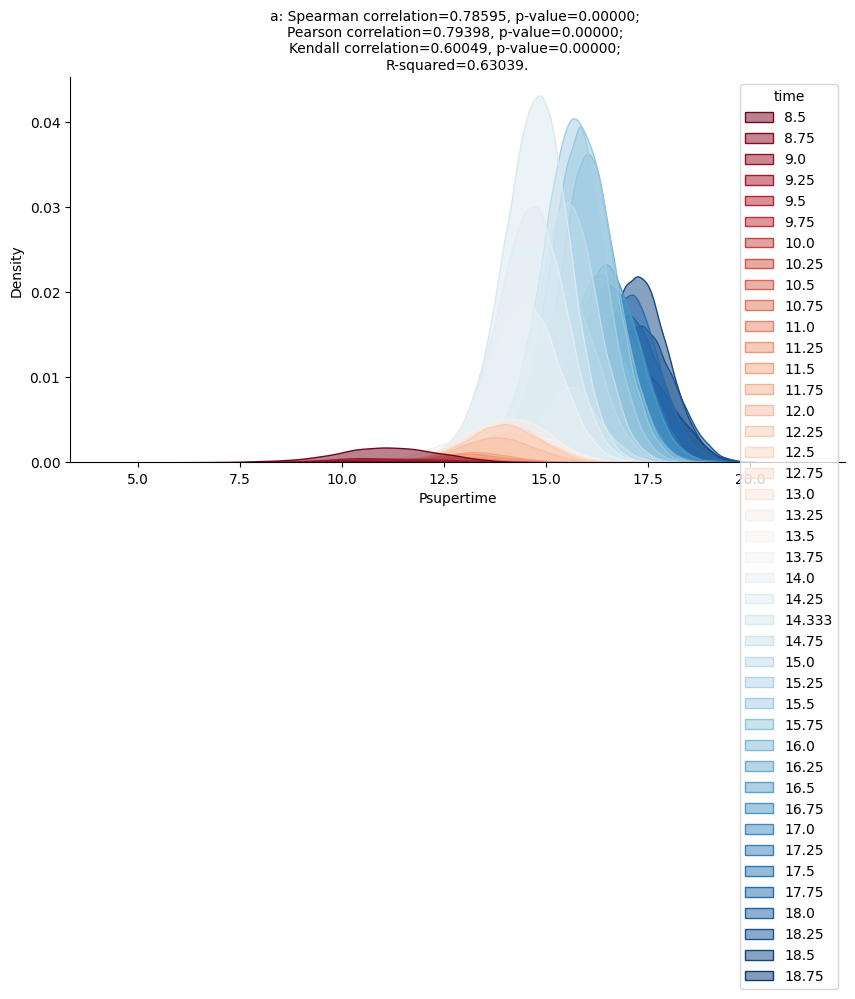

figure save at results/240509_kFold_mouse_atlas_data_onlyTestTime/linearRegression_atlas//a_labelsOverPsupertime.png
figure save at results/240509_kFold_mouse_atlas_data_onlyTestTime/linearRegression_atlas//labelsOverPsupertime.png


In [3]:
LR()



# PCA

In [6]:
from sklearn.decomposition import PCA
def PCA_awa():
    method = "PCA"
    save_path=f"results/Fig3_science2022_LR_PCA_RF_kFoldOn_mouseAtlas_240901/{method}_atlas/"


    if not os.path.exists(save_path):
        os.makedirs(save_path)
    data_golbal_path = "data/"
    data_path = "/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/"
    sc_data_file_csv = f"{data_path}/data_count_hvg.csv"
    cell_info_file_csv = f"{data_path}/cell_with_time.csv"

    # ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
    logger_file = f'{save_path}/{method}_run.log'
    LogHelper.setup(log_path=logger_file, level='INFO')
    _logger = logging.getLogger(__name__)
    _logger.info("Finished setting up the logger at: {}.".format(logger_file))
    _logger.info("Train on dataset: {}.".format(data_golbal_path + data_path))

    sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path, sc_data_file_csv, cell_info_file_csv,
                                                                                min_cell_num=50,
                                                                                min_gene_num=100)
    # ---------------------------------------- set donor list and dictionary -----------------------------------------------------
    donor_list = np.unique(cell_time["donor"])
    donor_list = sorted(donor_list, key=Embryodonor_resort_key)
    donor_dic = dict()
    for i in range(len(donor_list)):
        donor_dic[donor_list[i]] = i
    batch_dic = donor_dic.copy()
    print("Consider donor as batch effect, donor use label: {}".format(donor_dic))
    print("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["donor"])))

    kFold_test_result_df = pd.DataFrame(columns=['time', 'pseudotime'])

    # use one donor as test set, other as train set
    adata = ad.AnnData(X=sc_expression_df,obs=cell_time)
    print(len(donor_list))
    for donor in donor_list:
        # donor = "embryo_1"
        # start_time = time.time()

        train_adata = adata[adata.obs["donor"] != donor].copy()
        test_adata = adata[adata.obs["donor"] == donor].copy()
        # initiate PCA and classifier
        pca = PCA(n_components=2)
        # classifier = DecisionTreeClassifier()
        # transform / fit
        train_lowDim = pca.fit_transform(train_adata.X)
        # classifier.fit(train_lowDim, train_adata.obs["time"])
        # predict "new" data
        test_lowDim = pca.transform(test_adata.X)
        # predict labels using the trained classifier
        test_result_df = pd.DataFrame(test_adata.obs["time"])
        test_result_df["pseudotime"] = test_lowDim[:, 0]
        # test_result_df["pseudotime"] = classifier.predict(test_lowDim)

        kFold_test_result_df = pd.concat([kFold_test_result_df, test_result_df], axis=0)
        # end_time = time.time()
        # elapsed_time = end_time - start_time
        # _logger.info(f"**** Total execution time: {elapsed_time} seconds **** k-fold on {donor}")
        # exit(1)
    print("k-fold test final result:")
    corr(kFold_test_result_df["time"], kFold_test_result_df["pseudotime"])
    kFold_test_result_df.to_csv(f'{save_path}/result_df.csv', index=True)
    print(f"test result save at {save_path}/result_df.csv")

    plot_psupertime_density(kFold_test_result_df,save_path, label_key="time", psupertime_key="pseudotime")
    print(f"figure save at {save_path}/labelsOverPsupertime.png")

2024-05-09 22:26:05,860 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/PCA_atlas//PCA_run.log. 
2024-05-09 22:26:05,860 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/PCA_atlas//PCA_run.log. 
2024-05-09 22:26:05,860 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/PCA_atlas//PCA_run.log. 
2024-05-09 22:26:05,862 INFO - __main__ - Train on dataset: data//mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/. 
2024-05-09 22:26:05,862 INFO - __main__ - Train on dataset: data//mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/. 
2024-05-09 22:26:05,862 INFO - __main__ - Train on dataset: data//mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/. 
2024-05-09 22:26:05,863 INFO - utils.utils_DandanPro

Consider donor as batch effect, donor use label: {'embryo_1': 0, 'embryo_2': 1, 'embryo_3': 2, 'embryo_4': 3, 'embryo_5': 4, 'embryo_6': 5, 'embryo_7': 6, 'embryo_8': 7, 'embryo_9': 8, 'embryo_10': 9, 'embryo_11': 10, 'embryo_12': 11, 'embryo_13': 12, 'embryo_14': 13, 'embryo_15': 14, 'embryo_16': 15, 'embryo_17': 16, 'embryo_18': 17, 'embryo_19': 18, 'embryo_20': 19, 'embryo_21': 20, 'embryo_22': 21, 'embryo_23': 22, 'embryo_24': 23, 'embryo_25': 24, 'embryo_26': 25, 'embryo_27': 26, 'embryo_28': 27, 'embryo_29': 28, 'embryo_30': 29, 'embryo_31': 30, 'embryo_32': 31, 'embryo_33': 32, 'embryo_34': 33, 'embryo_35': 34, 'embryo_36': 35, 'embryo_37': 36, 'embryo_38': 37, 'embryo_39': 38, 'embryo_40': 39, 'embryo_41': 40, 'embryo_42': 41, 'embryo_43': 42, 'embryo_44': 43, 'embryo_45': 44, 'embryo_46': 45, 'embryo_47': 46, 'embryo_48': 47, 'embryo_49': 48, 'embryo_50': 49, 'embryo_51': 50, 'embryo_52': 51, 'embryo_53': 52, 'embryo_54': 53, 'embryo_55': 54, 'embryo_56': 55, 'embryo_57': 56, 

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_945530/1120391.py:37: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=sc_expression_df,obs=cell_time)


72
k-fold test final result:
 spearman correlation score: -0.2516119253589385, p-value: 0.0.
 kendalltau correlation score: -0.16164828147910537,p-value: 0.0.
test result save at results/240509_kFold_mouse_atlas_data_onlyTestTime/PCA_atlas//result_df.csv


/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/utils/utils_Dandan_plot.py:1442: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


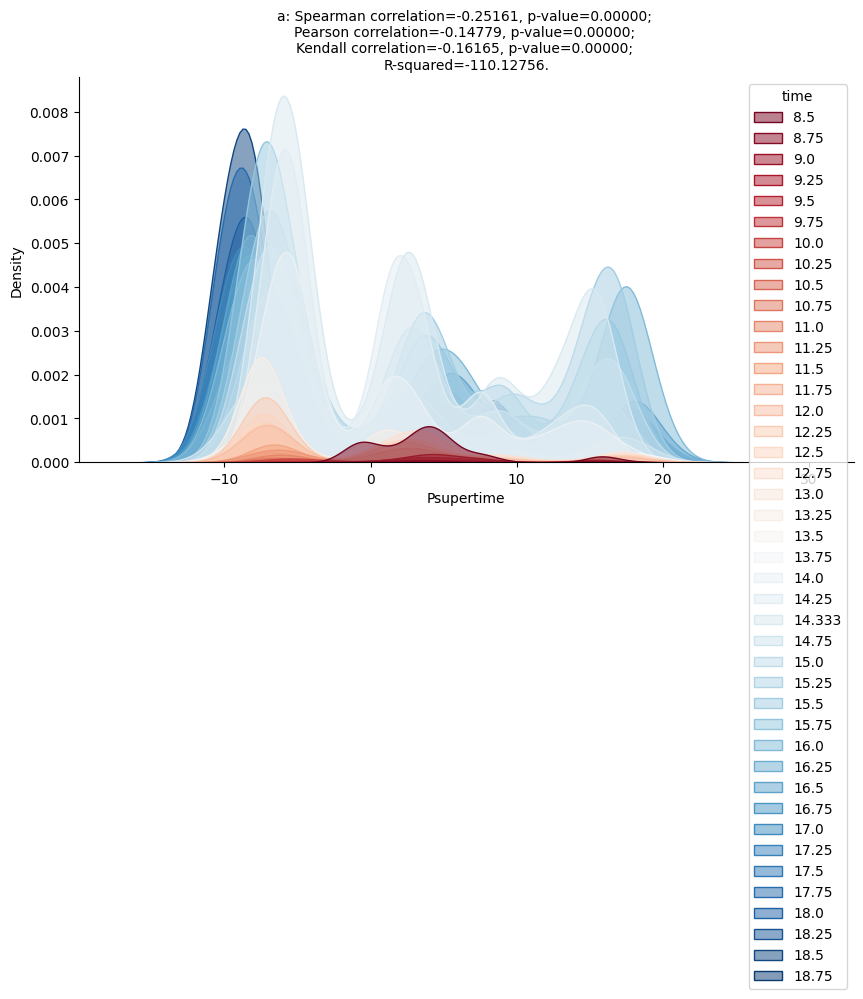

figure save at results/240509_kFold_mouse_atlas_data_onlyTestTime/PCA_atlas//a_labelsOverPsupertime.png
figure save at results/240509_kFold_mouse_atlas_data_onlyTestTime/PCA_atlas//labelsOverPsupertime.png


In [7]:

PCA_awa()


# RF

In [16]:
def RF_awa():
    method = "randomForest"
    save_path=f"results/Fig3_science2022_LR_PCA_RF_kFoldOn_mouseAtlas_240901/{method}_atlas/"

    if not os.path.exists(save_path):
        os.makedirs(save_path)
    data_golbal_path = "data/"
    data_path = "/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/"
    sc_data_file_csv = f"{data_path}/data_count_hvg.csv"
    cell_info_file_csv = f"{data_path}/cell_with_time.csv"

    # ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
    logger_file = f'{save_path}/{method}_run.log'
    LogHelper.setup(log_path=logger_file, level='INFO')
    _logger = logging.getLogger(__name__)
    _logger.info("Finished setting up the logger at: {}.".format(logger_file))
    _logger.info("Train on dataset: {}.".format(data_golbal_path + data_path))

    sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path, sc_data_file_csv, cell_info_file_csv,
                                                                                min_cell_num=50,
                                                                                min_gene_num=100)
    # ---------------------------------------- set donor list and dictionary -----------------------------------------------------
    donor_list = np.unique(cell_time["donor"])
    donor_list = sorted(donor_list, key=Embryodonor_resort_key)
    donor_dic = dict()
    for i in range(len(donor_list)):
        donor_dic[donor_list[i]] = i
    # batch_dic = donor_dic.copy()
    print("Consider donor as batch effect, donor use label: {}".format(donor_dic))
    print("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["donor"])))

    kFold_test_result_df = pd.DataFrame(columns=['time', 'pseudotime'])

    # use one donor as test set, other as train set
    adata = ad.AnnData(X=sc_expression_df,obs=cell_time)
    print(len(donor_list))
    for donor in donor_list:
        train_adata = adata[adata.obs["donor"] != donor].copy()
        test_adata = adata[adata.obs["donor"] == donor].copy()
        RF_model = random_forest_regressor(train_x=train_adata.X, train_y=train_adata.obs["time"])
        test_y_predicted = RF_model.predict(test_adata.X)

        test_result_df = pd.DataFrame(test_adata.obs["time"],index=test_adata.obs.index)
        test_result_df["pseudotime"] = test_y_predicted

        kFold_test_result_df = pd.concat([kFold_test_result_df, test_result_df], axis=0)
    print("k-fold test final result:")
    corr(kFold_test_result_df["time"], kFold_test_result_df["pseudotime"])
    kFold_test_result_df.to_csv(f'{save_path}/result_df.csv', index=True)
    print(f"test result save at {save_path}/result_df.csv")

    plot_psupertime_density(kFold_test_result_df,save_path, label_key="time", psupertime_key="pseudotime")
    print(f"figure save at {save_path}/labelsOverPsupertime.png")
def random_forest_regressor(train_x, train_y):
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(max_depth=2, random_state=0)
    model.fit(train_x, train_y)
    return model

2024-05-11 07:37:56,399 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//randomForest_run.log. 
2024-05-11 07:37:56,399 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//randomForest_run.log. 
2024-05-11 07:37:56,399 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//randomForest_run.log. 
2024-05-11 07:37:56,399 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//randomForest_run.log. 
2024-05-11 07:37:56,399 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//randomForest_run.log. 
2024-05-11 07:37:56,399 INFO - __main__ - Finished setting up the logger at: results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atla

2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:10,374 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-11 07:40:17,541 INFO - utils.utils_DandanProject - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2024-05-11 07:40:17,541

Consider donor as batch effect, donor use label: {'embryo_1': 0, 'embryo_2': 1, 'embryo_3': 2, 'embryo_4': 3, 'embryo_5': 4, 'embryo_6': 5, 'embryo_7': 6, 'embryo_8': 7, 'embryo_9': 8, 'embryo_10': 9, 'embryo_11': 10, 'embryo_12': 11, 'embryo_13': 12, 'embryo_14': 13, 'embryo_15': 14, 'embryo_16': 15, 'embryo_17': 16, 'embryo_18': 17, 'embryo_19': 18, 'embryo_20': 19, 'embryo_21': 20, 'embryo_22': 21, 'embryo_23': 22, 'embryo_24': 23, 'embryo_25': 24, 'embryo_26': 25, 'embryo_27': 26, 'embryo_28': 27, 'embryo_29': 28, 'embryo_30': 29, 'embryo_31': 30, 'embryo_32': 31, 'embryo_33': 32, 'embryo_34': 33, 'embryo_35': 34, 'embryo_36': 35, 'embryo_37': 36, 'embryo_38': 37, 'embryo_39': 38, 'embryo_40': 39, 'embryo_41': 40, 'embryo_42': 41, 'embryo_43': 42, 'embryo_44': 43, 'embryo_45': 44, 'embryo_46': 45, 'embryo_47': 46, 'embryo_48': 47, 'embryo_49': 48, 'embryo_50': 49, 'embryo_51': 50, 'embryo_52': 51, 'embryo_53': 52, 'embryo_54': 53, 'embryo_55': 54, 'embryo_56': 55, 'embryo_57': 56, 

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_945530/3419482944.py:35: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=sc_expression_df,obs=cell_time)


72
k-fold test final result:
 spearman correlation score: -0.0716803135341251, p-value: 0.0.
 kendalltau correlation score: -0.15779914533725672,p-value: 0.0.


/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


test result save at results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//result_df.csv


/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))
/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/utils/utils_Dandan_plot.py:1442: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


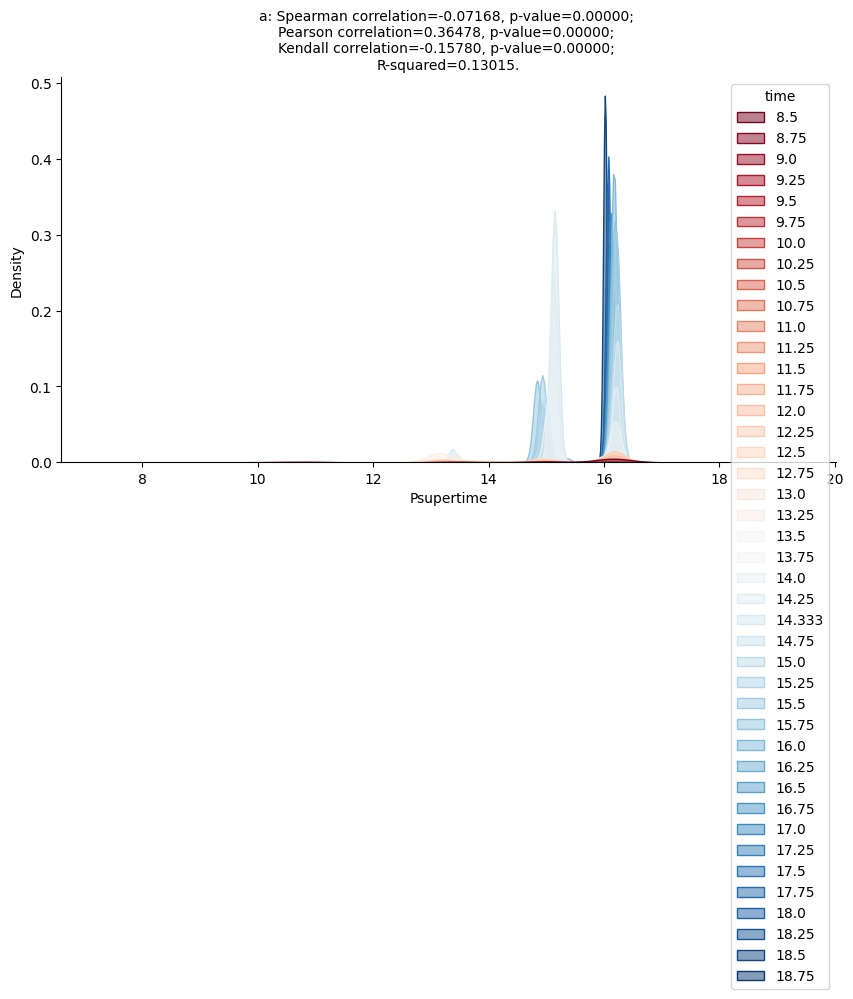

figure save at results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//a_labelsOverPsupertime.png
figure save at results/240509_kFold_mouse_atlas_data_onlyTestTime/randomForest_atlas//labelsOverPsupertime.png


In [17]:
RF_awa()


# read TemporalVAE result, and compare with baseline methods

In [3]:
from TemporalVAE.utils import calculate_real_predict_corrlation_score
import pandas as pd
# ----------------------- k-fold on mouse atlas data, for temporalVAE compare with LR, PCA, RF -----------------------
file_name = "results/240902_vae_kfoldOn_mouseAtlas_testRemoveTanh/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch100_minGeneNum100/k_fold_test_result.csv"
data_pd = pd.read_csv(file_name)
VAE = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["predicted_time"])
VAE

'Spearman correlation=0.89012, p-value=0.00000; \nPearson correlation=0.91359, p-value=0.00000; \nKendall correlation=0.72915, p-value=0.00000; \nR-squared=0.83391.'

In [4]:
file_name="results/240901_science2022_kFoldOn_mouseAtlas/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/science_timeembryoneg5to5_minGeneNum100/k_fold_test_result.csv"
data_pd=pd.read_csv(file_name)
science=calculate_real_predict_corrlation_score(data_pd["stage"],data_pd["predicted_time"])
science

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


'Spearman correlation=0.83787, p-value=0.00000; \nPearson correlation=0.79336, p-value=0.00000; \nKendall correlation=0.65749, p-value=0.00000; \nR-squared=0.60719.'

In [5]:
file_name = "results/Fig3_science2022_LR_PCA_RF_kFoldOn_mouseAtlas_240901/linearRegression_atlas/result_df.csv"
data_pd = pd.read_csv(file_name)
LR = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"])
LR

'Spearman correlation=0.78595, p-value=0.00000; \nPearson correlation=0.79398, p-value=0.00000; \nKendall correlation=0.60049, p-value=0.00000; \nR-squared=0.63039.'

In [6]:
file_name = "results/Fig3_science2022_LR_PCA_RF_kFoldOn_mouseAtlas_240901/PCA_atlas/result_df.csv"
data_pd = pd.read_csv(file_name)
PCA = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"])
PCA

'Spearman correlation=-0.25161, p-value=0.00000; \nPearson correlation=-0.14779, p-value=0.00000; \nKendall correlation=-0.16165, p-value=0.00000; \nR-squared=-110.12756.'

In [7]:
file_name = "results/Fig3_science2022_LR_PCA_RF_kFoldOn_mouseAtlas_240901/randomForest_atlas/result_df.csv"
data_pd = pd.read_csv(file_name)
RF = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"])
RF

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


'Spearman correlation=-0.07168, p-value=0.00000; \nPearson correlation=0.36478, p-value=0.00000; \nKendall correlation=-0.15780, p-value=0.00000; \nR-squared=0.13015.'

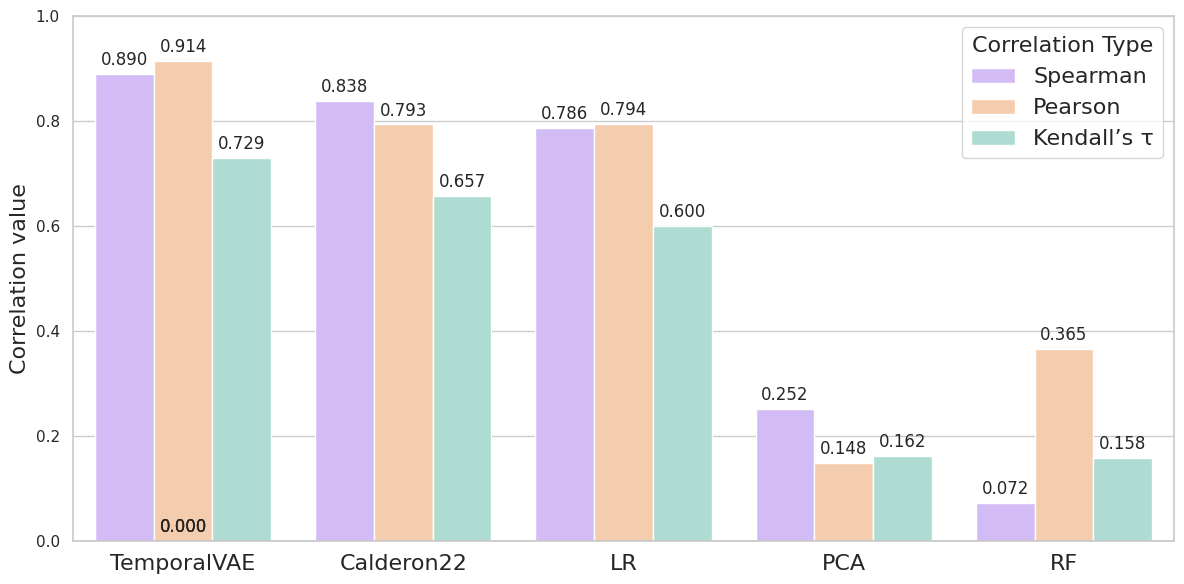

In [1]:
data = {
    'Method': ['TemporalVAE', 'TemporalVAE',  'TemporalVAE', 
               'Calderon22','Calderon22','Calderon22',
               'LR', 'LR', 'LR',
               'PCA', 'PCA', 'PCA', 
               "RF", "RF","RF"],
    'Correlation Type': ['Spearman', 'Pearson','Kendall’s τ',
                         'Spearman', 'Pearson', 'Kendall’s τ',
                         'Spearman', 'Pearson', 'Kendall’s τ',
                         'Spearman', 'Pearson', 'Kendall’s τ',
                         'Spearman', 'Pearson','Kendall’s τ',],
    'Value': [0.89012, 0.91359,0.72915,
              0.83787,0.79336,0.65749,
              0.78595, 0.79398, 0.60049,
              0.25161, 0.14779,0.16165,
              0.07168, 0.36478,0.15780]
}

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# for "embryo_1"
# time_dic={"TemporalVAE":2161.1639816761017,}
df = pd.DataFrame(data)

# 设置绘图风格
sns.set(style="whitegrid")

# 创建条形图
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x='Method', y='Value', hue='Correlation Type', data=df, palette=["#D1B2FF", "#FFCBA4","#A6E3D7"])

# 添加标题和坐标轴标签
plt.title('', fontsize=16)
plt.ylabel('Correlation value', fontsize=16)
plt.xlabel('', fontsize=15)

# 调整图例
plt.legend(title='Correlation Type', title_fontsize='16', fontsize='16')

# 在每个条形上显示数值
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10),
                     textcoords='offset points')

# 设置Y轴范围以清晰展示负相关性，添加Y=0参考线强调正负相关性
plt.ylim(0, 1)
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# 设置x轴标签的字体大小
plt.tick_params(axis='x', labelsize=16)  # Set x-axis label size to 14


# 美化图表
# sns.despine(offset=10, trim=True)  # 减少边框
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 显示图表
plt.show()